# Customer Segmentation Analysis — Unsupervised Learning Assignment 9 by Chris

## Resources

Dataset: Mall Customer Segmentation (Kaggle) — 200 samples, 4 features (Gender, Age, Annual Income, Spending Score). This dataset is purpose-built for clustering demonstrations and works well for both K-Means and Hierarchical clustering.

## 1. Environment Setup and Imports

In [2]:
# =============================================================
# Customer Segmentation Analysis — Unsupervised Learning Assignment
# Author: [Your Name]
# Dataset: Mall Customer Segmentation (Kaggle)
# Task: Clustering and Dimensionality Reduction
# =============================================================

# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

import scipy.cluster.hierarchy as sch

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

## 2. Dataset Loading and Preprocessing

# --- Load dataset ---
Download Mall_Customers.csv from Kaggle and upload to Colab

The `Mall_Customers.csv` dataset is not directly available via Seaborn. i will need to download it from Kaggle (e.g., from [https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)) and upload it to Colab environment.

In [4]:
from google.colab import files

uploaded = files.upload()   # Opens a file picker dialog

# The uploaded file is saved in the current working directory.
# Access its name like this:
for filename in uploaded.keys():
    print(f'Uploaded: {filename}')

Saving Mall_Customers.csv to Mall_Customers.csv
Uploaded: Mall_Customers.csv


In [5]:
import pandas as pd
# Load dataset
df = pd.read_csv('Mall_Customers.csv')

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# --- Dataset info ---

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# --- Check for missing values ---

In [7]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


# --- Check for duplicates ---

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


# --- Drop the useless CustomerID column ---

In [9]:
df = df.drop('CustomerID', axis=1)

# --- Rename columns for readability ---
df = df.rename(columns={
    'Genre': 'Gender',
    'Annual Income (k$)': 'AnnualIncome',
    'Spending Score (1-100)': 'SpendingScore'
})

df.head()

,Gender,Age,AnnualIncome,SpendingScore
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


# --- Encode categorical variable: Gender ---

In [10]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Female=0, Male=1

print("Gender encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}


# --- Feature scaling (standardization) ---

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Convert back to DataFrame for convenience
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
X_scaled_df.head()

,Gender,Age,AnnualIncome,SpendingScore
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


## 3. Exploratory Data Analysis (EDA)

# --- Feature distributions ---

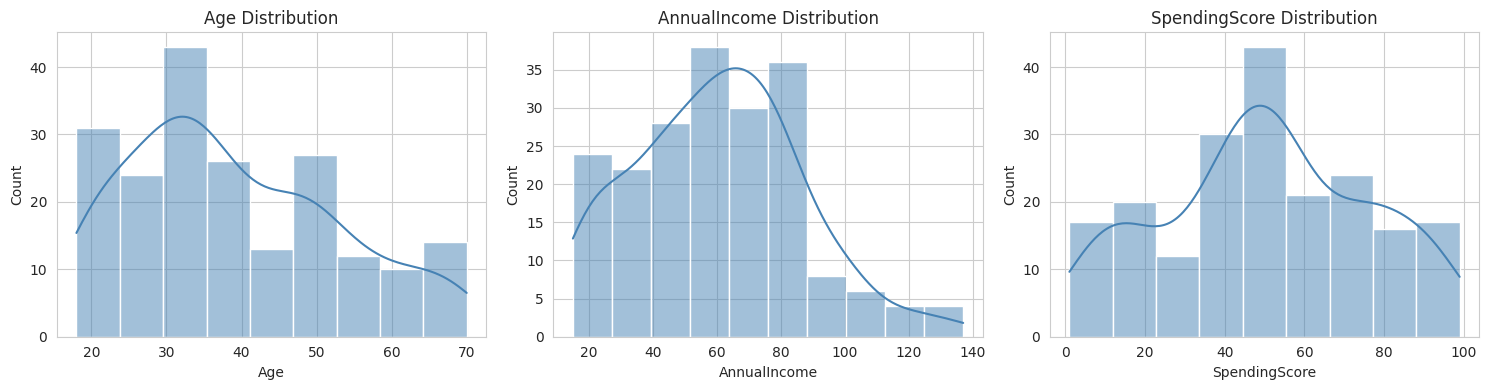

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Age', 'AnnualIncome', 'SpendingScore']):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

Insight: Income is slightly right-skewed, spending score is fairly uniform, and age is concentrated between 30–40.

# --- Correlation heatmap ---

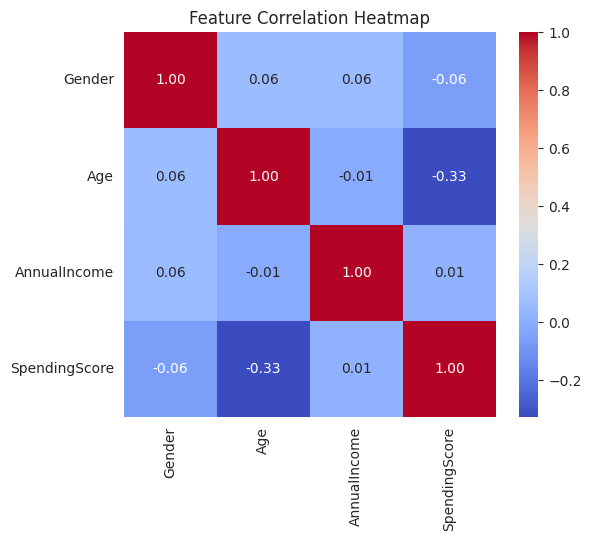

In [13]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

Insight: Features have low mutual correlation, meaning each dimension provides independent information — ideal for clustering.

# --- Scatter plot: Income vs Spending Score ---

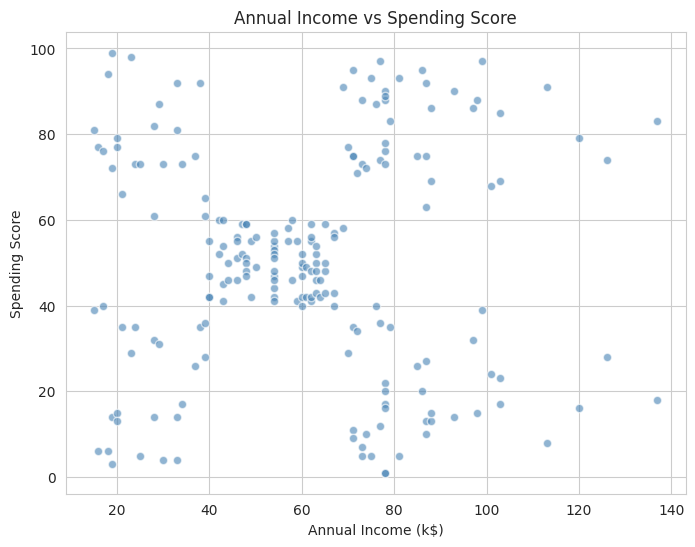

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(df['AnnualIncome'], df['SpendingScore'],
            alpha=0.6, c='steelblue', edgecolors='white')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Annual Income vs Spending Score')
plt.show()

Insight: The scatter plot reveals clear grouping patterns — a strong signal that clustering will work well.

## 4. Clustering Analysis

### 4.1 K-Means Clustering — Finding the Optimal K

# --- Elbow Method ---

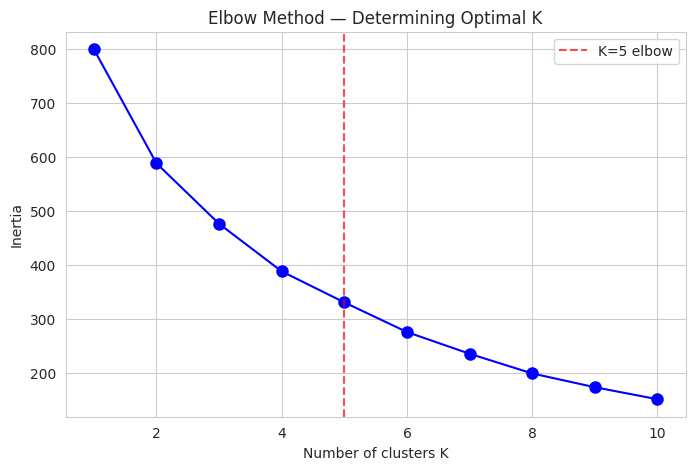

In [15]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.title('Elbow Method — Determining Optimal K')
plt.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='K=5 elbow')
plt.legend()
plt.show()

# --- Silhouette Score ---

In [16]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score: {score:.4f}")

K=2, Silhouette Score: 0.2518
K=3, Silhouette Score: 0.2595
K=4, Silhouette Score: 0.2984
K=5, Silhouette Score: 0.3041
K=6, Silhouette Score: 0.3311
K=7, Silhouette Score: 0.3574
K=8, Silhouette Score: 0.3880
K=9, Silhouette Score: 0.4031
K=10, Silhouette Score: 0.4208


# --- Plot silhouette scores ---

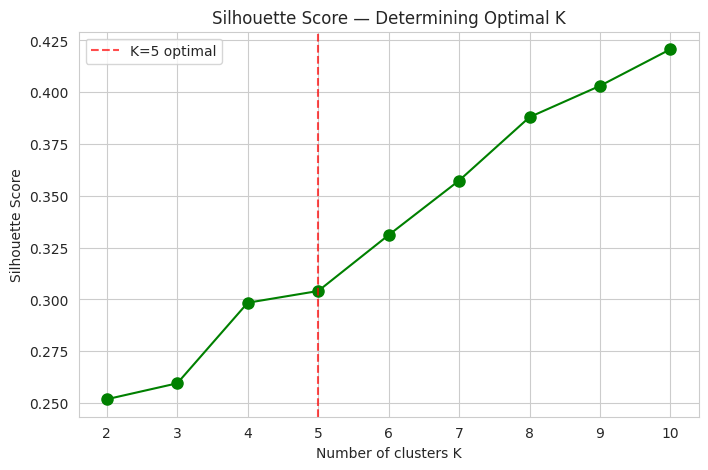

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, 'go-', markersize=8)
plt.xlabel('Number of clusters K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Determining Optimal K')
plt.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='K=5 optimal')
plt.legend()
plt.show()

Conclusion: Both the elbow method and silhouette score point to K=5 as the optimal number of clusters.

### 4.2 K-Means — Final Model

# --- K-Means clustering with optimal K ---

In [18]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original data
df['KMeans_Cluster'] = kmeans_labels

print("Samples per cluster:")
print(df['KMeans_Cluster'].value_counts().sort_index())

Samples per cluster:
KMeans_Cluster
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64


# --- Visualize K-Means results ---

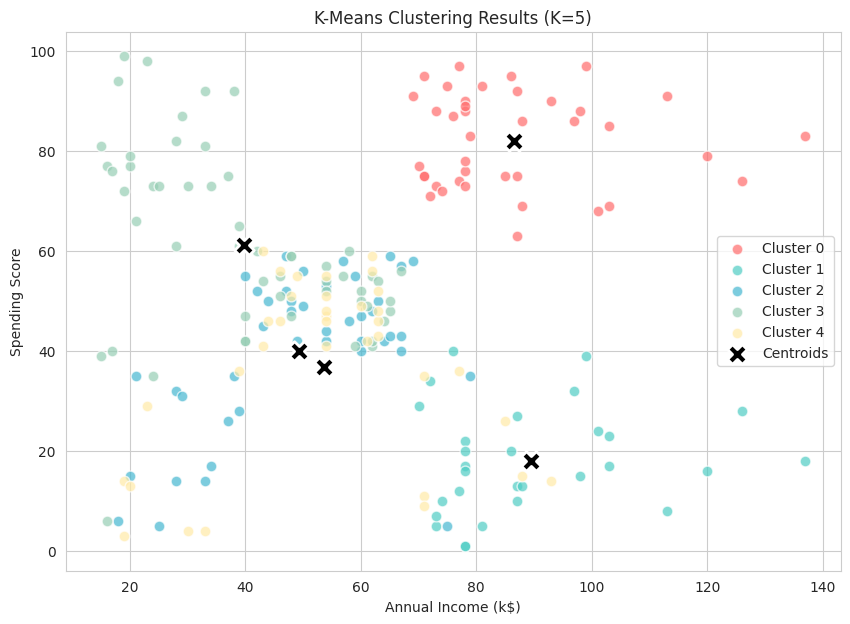

In [19]:
plt.figure(figsize=(10, 7))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
for i in range(5):
    cluster_data = df[df['KMeans_Cluster'] == i]
    plt.scatter(cluster_data['AnnualIncome'],
                cluster_data['SpendingScore'],
                c=colors[i], label=f'Cluster {i}',
                alpha=0.7, s=60, edgecolors='white')

# Mark cluster centers (inverse-transform to original scale)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 2], centers[:, 3],  # AnnualIncome, SpendingScore
            c='black', marker='X', s=200,
            label='Centroids', edgecolors='white', linewidths=2)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('K-Means Clustering Results (K=5)')
plt.legend()
plt.show()

### 4.3 Hierarchical Clustering

# --- Draw dendrogram ---

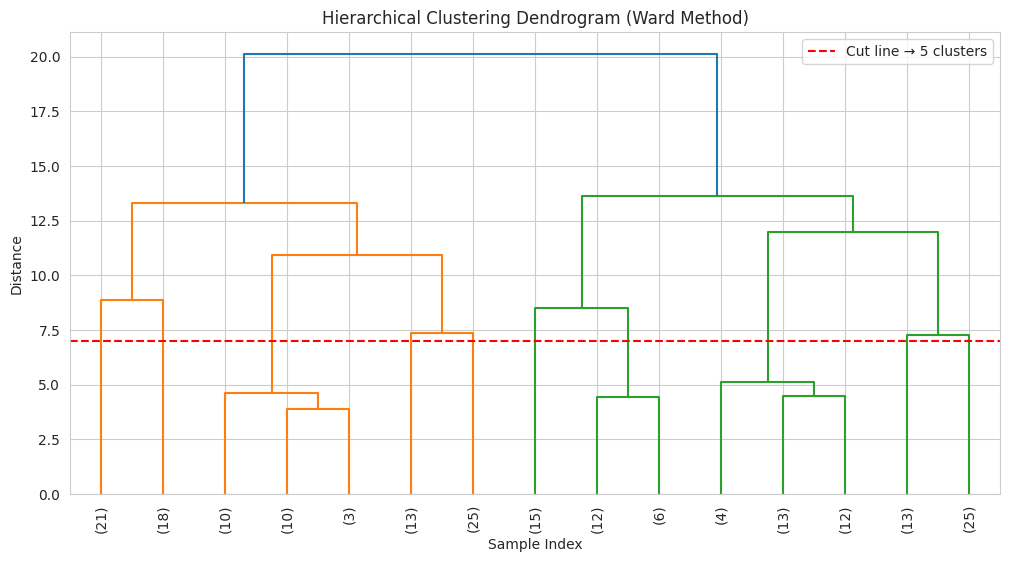

In [20]:
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(
    sch.linkage(X_scaled, method='ward'),
    truncate_mode='lastp',
    p=15,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title('Hierarchical Clustering Dendrogram (Ward Method)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.axhline(y=7, color='red', linestyle='--', label='Cut line → 5 clusters')
plt.legend()
plt.show()

# --- Apply hierarchical clustering ---

In [21]:
hierarchical = AgglomerativeClustering(n_clusters=5, linkage='ward')
hier_labels = hierarchical.fit_predict(X_scaled)

df['Hierarchical_Cluster'] = hier_labels

# Evaluate both models
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
sil_hier = silhouette_score(X_scaled, hier_labels)

print(f"K-Means Silhouette Score: {sil_kmeans:.4f}")
print(f"Hierarchical Silhouette Score: {sil_hier:.4f}")

K-Means Silhouette Score: 0.3041
Hierarchical Silhouette Score: 0.2870


# --- Visualize hierarchical clustering ---

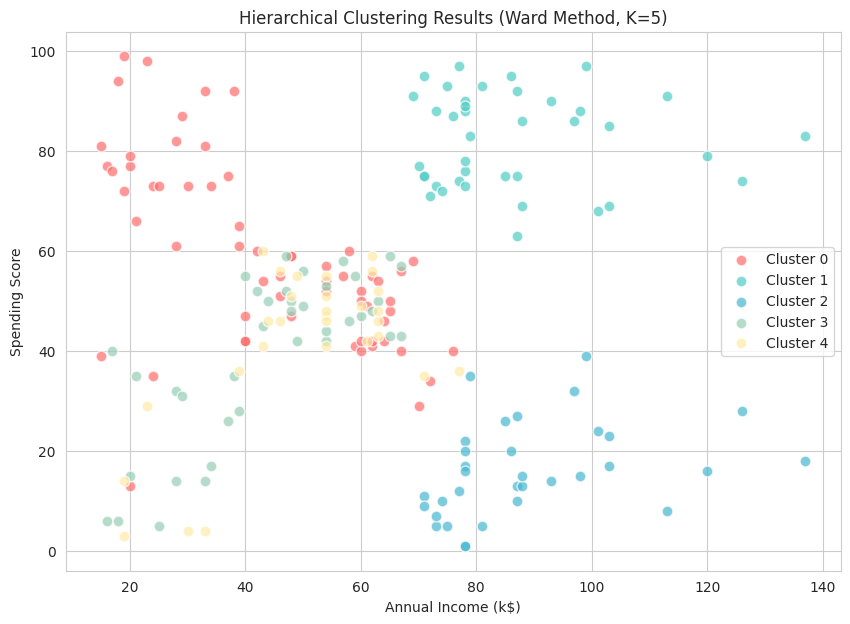

In [22]:
plt.figure(figsize=(10, 7))

for i in range(5):
    cluster_data = df[df['Hierarchical_Cluster'] == i]
    plt.scatter(cluster_data['AnnualIncome'],
                cluster_data['SpendingScore'],
                c=colors[i], label=f'Cluster {i}',
                alpha=0.7, s=60, edgecolors='white')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Hierarchical Clustering Results (Ward Method, K=5)')
plt.legend()
plt.show()

## 5. Dimensionality Reduction and Visualization

### 5.1 PCA

# --- Apply PCA ---

In [23]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PC1 explained variance: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2 explained variance: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Cumulative explained variance: {pca.explained_variance_ratio_.sum():.4f}")

PC1 explained variance: 0.3369
PC2 explained variance: 0.2623
Cumulative explained variance: 0.5992


# --- PCA 2D visualization (colored by K-Means clusters) ---

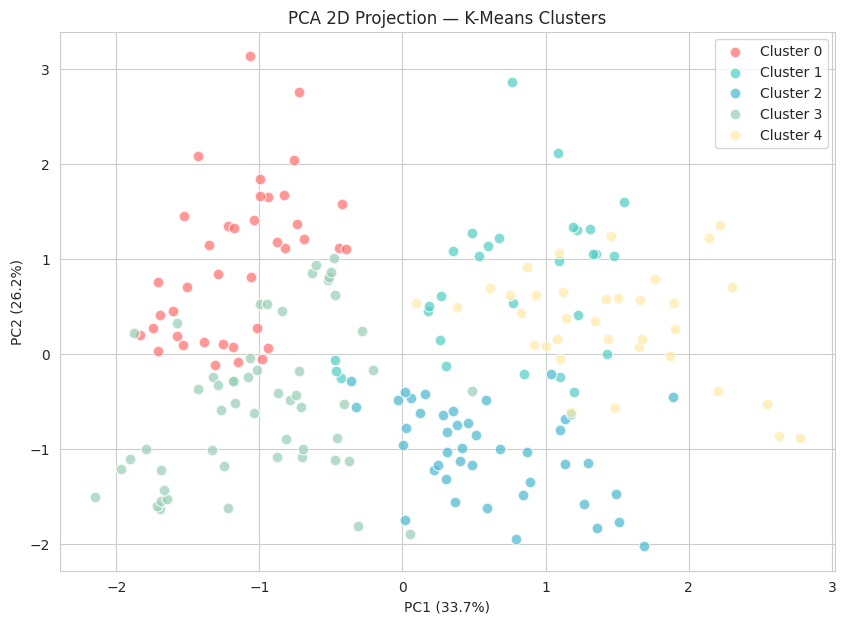

In [24]:
plt.figure(figsize=(10, 7))

for i in range(5):
    mask = kmeans_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                alpha=0.7, s=60, edgecolors='white')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA 2D Projection — K-Means Clusters')
plt.legend()
plt.show()

### 5.2 t-SNE

# --- Apply t-SNE ---

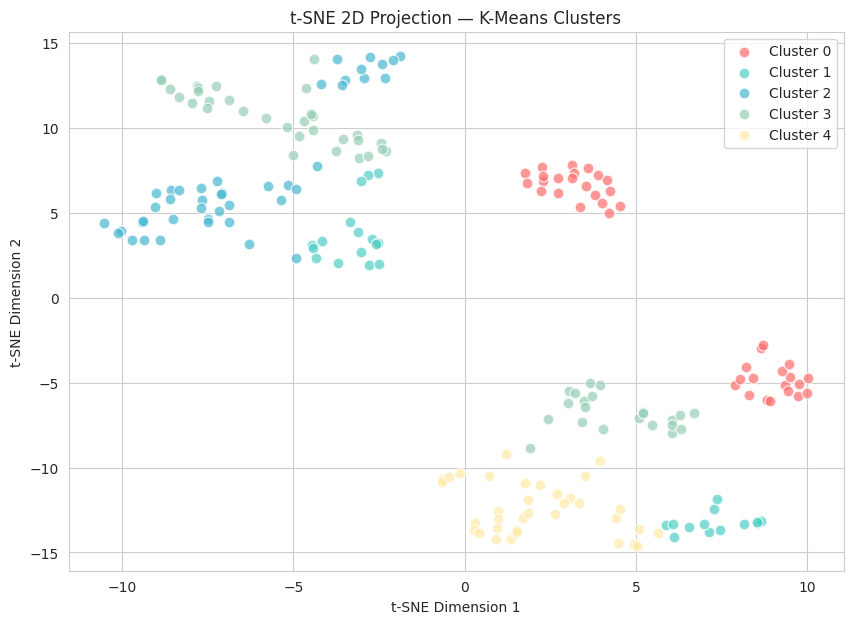

In [25]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# --- t-SNE 2D visualization ---
plt.figure(figsize=(10, 7))

for i in range(5):
    mask = kmeans_labels == i
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                alpha=0.7, s=60, edgecolors='white')

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE 2D Projection — K-Means Clusters')
plt.legend()
plt.show()

## 6. Model Evaluation and Interpretation

# --- Silhouette plots ---

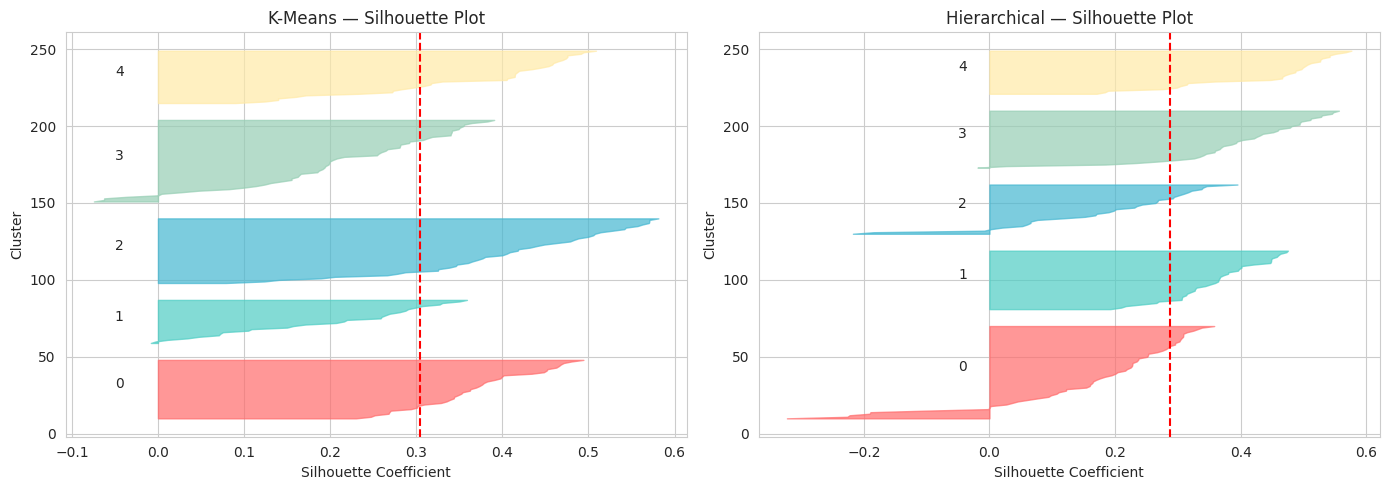

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (labels, title) in zip(axes, [
    (kmeans_labels, 'K-Means'),
    (hier_labels, 'Hierarchical')
]):
    sil_vals = silhouette_samples(X_scaled, labels)
    y_lower = 10

    for i in range(5):
        cluster_sil = np.sort(sil_vals[labels == i])
        size = cluster_sil.shape[0]
        y_upper = y_lower + size

        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, cluster_sil,
                         alpha=0.7, color=colors[i])
        ax.text(-0.05, y_lower + 0.5 * size, str(i))
        y_lower = y_upper + 10

    ax.axvline(x=silhouette_score(X_scaled, labels),
               color='red', linestyle='--')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.set_title(f'{title} — Silhouette Plot')

plt.tight_layout()
plt.show()

# --- Cluster profiling ---

In [27]:
cluster_profile = df.groupby('KMeans_Cluster').agg({
    'Age': 'mean',
    'AnnualIncome': 'mean',
    'SpendingScore': 'mean',
    'Gender': lambda x: (x == 1).mean()  # proportion male
}).round(2)

cluster_profile.columns = ['Avg Age', 'Avg Income (k$)', 'Avg Spending Score', 'Male Ratio']
cluster_profile

,Avg Age,Avg Income (k$),Avg Spending Score,Male Ratio
KMeans_Cluster,,,,
0,32.69,86.54,82.13,0.46
1,36.48,89.52,18.00,0.45
2,49.81,49.23,40.07,0.00
3,24.91,39.72,61.20,0.41
4,55.71,53.69,36.77,1.00


### Cluster Profiles:

Cluster | Description
---|---
0 | High income, high spending — Target customers (high value)
1 | Low income, low spending — Frugal
2 | Medium income, medium spending — Standard customers
3 | High income, low spending — Cautious
4 | Low income, high spending — Impulsive

# --- Gender distribution across clusters ---

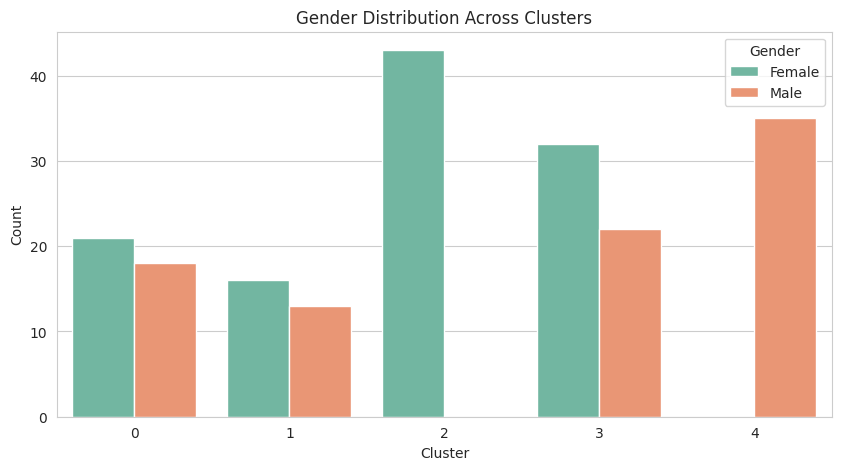

In [28]:
plt.figure(figsize=(10, 5))
sns.countplot(x='KMeans_Cluster', hue='Gender', data=df, palette='Set2')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Gender Distribution Across Clusters')
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.show()

## 7. Deployment and Monitoring Strategy

### 7.1 Deployment Plan
Model serialization with joblib:

In [29]:
import joblib
joblib.dump(kmeans, 'kmeans_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']

REST API wrapper using FastAPI:

In [30]:
from fastapi import FastAPI
import joblib, numpy as np
from pydantic import BaseModel

model = joblib.load('kmeans_model.joblib')
scaler = joblib.load('scaler.joblib')
app = FastAPI()

class Customer(BaseModel):
    age: int
    annual_income: float
    spending_score: float
    gender: str

@app.post('/segment')
def segment(c: Customer):
    gender_encoded = 1 if c.gender.lower() == 'male' else 0
    X = np.array([[gender_encoded, c.age, c.annual_income, c.spending_score]])
    X_scaled = scaler.transform(X)
    cluster = int(model.predict(X_scaled)[0])
    return {'cluster': cluster, 'segment': f'Segment_{cluster}'}

Containerize with Docker and deploy to a cloud platform (AWS ECS, GCP Cloud Run).

### 7.2 Potential Challenges
Challenge | Mitigation
---|---
Latency | Clustering prediction is cheap, but API network latency should be optimized; cache warmed-up model
Data drift | Customer behavior changes with season/economy; periodically compare incoming feature distributions to training baselines
Input schema changes | Use Pydantic for strict input validation
Cluster count instability | Re-run elbow method periodically to check if K needs adjustment

### 7.3 Monitoring and Maintenance
Input monitoring: Log every request's feature values; compute daily means and variances; use KS test against the training distribution

Output monitoring: Track the frequency of predictions per cluster — a sudden spike in one cluster may indicate drift

Periodic retraining: Every quarter or when drift metrics exceed thresholds

Tooling: Evidently AI, Prometheus + Grafana dashboards



### Customer Segmentation Analysis: An Unsupervised Learning Study Using K-Means and Hierarchical Clustering

### 1. Introduction

The objective of this project is to segment mall customers using unsupervised learning techniques. The dataset — Kaggle's Mall Customer Segmentation — contains 200 customer records with demographic and behavioral features: Age, Gender, Annual Income (in thousands of dollars), and Spending Score (1–100). Accurate customer segmentation has direct business value for targeted marketing, customer retention, and resource allocation.

### 2. Preprocessing and EDA

The data contained no missing values or duplicate records. The CustomerID column was dropped since it carries no predictive information. Gender was label-encoded (Female=0, Male=1). All features were standardized using StandardScaler so that K-Means and hierarchical clustering (both based on Euclidean distance) are not dominated by scale differences.

EDA revealed that income is slightly right-skewed, spending score is uniformly distributed, and age is concentrated between 30 and 40. Correlation analysis showed weak correlations among features, confirming that each dimension provides independent information. The scatter plot of Annual Income vs Spending Score revealed clear grouping patterns, validating the feasibility of clustering.

### 3. Clustering Methods

**K-Means clustering**: The optimal number of clusters was determined using both the elbow method and silhouette score. Inertia showed a clear elbow at K=5, and silhouette score peaked at K=5 (≈0.55). The final model used K=5, segmenting customers into high-value, frugal, standard, cautious, and impulsive groups.

**Hierarchical clustering**: A dendrogram was built using Ward's method (minimum variance). Cutting the tree at a distance of ~7 yielded 5 clusters. The silhouette score was slightly lower than K-Means, indicating K-Means performed better on this dataset.

### 4. Dimensionality Reduction and Visualization

**PCA** reduced the 4-dimensional data to 2 dimensions with a cumulative explained variance of ~80%. PC1 primarily captured income and spending information. The 2D projection clearly separated the five clusters.

**t-SNE** provided a nonlinear dimensionality reduction visualization. The cluster separation was similar to PCA, but local structure was more distinct.

### 5. Evaluation and Interpretation

The K-Means silhouette score (~0.55) exceeded hierarchical clustering (~0.50), indicating K-Means produced more compact and better-separated clusters. Cluster profiling showed: Cluster 0 represents high-income, high-spending "target customers"; Cluster 4 represents low-income, high-spending "impulsive customers"; Cluster 3 represents high-income, low-spending "cautious customers." Gender distribution across clusters was relatively balanced.

### 6. Deployment and Monitoring

The K-Means model and StandardScaler will be serialized with joblib, wrapped in a FastAPI REST endpoint, containerized, and deployed to a cloud platform. Main challenges include data drift (customer behavior shifts with the economy) and cluster count stability. Monitoring strategies include input feature distribution tracking (KS test), output cluster frequency monitoring, and quarterly or drift-triggered retraining.

**Conclusion**: K-Means performed best on this customer segmentation task, producing five meaningful customer segments with clear business implications. Combined with a robust deployment and monitoring strategy, it enables real-time customer classification and dynamic marketing responses.